# Single-frequency AAA_tube interpolation evaluated on a second complex tube

This notebook follows the `AAA_t_test3` workflow for one selected Matsubara frequency: build `G_app`, fit `AAA_tube` rational functions for `G_00` and `G_01`, then evaluate the fitted rational functions on a separate rectangular complex `t` tube.


In [1]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt

from t_interpolation_workflow import (
    compute_exact_t,
    build_t_app_G_app,
)
from _bary_rational import AAA_tube


In [2]:
# Same base parameter setup as AAA_t_test3.
beta = 20.0
Ns = 2
Nw = 4 * int(beta)
Mat_fre = (2 * np.linspace(0, Nw - 1, Nw) + 1) * np.pi / beta
wn = np.append(-np.flip(Mat_fre), Mat_fre)

shift = 0
U = 4.0
T = 20.0
Nt = 10001
t_values_ED = np.linspace(0, T, Nt) + shift

sce_order = 12
wce_order = 12
epsilon = 1e-6

# Select one Matsubara frequency to fit.
n_fit = Nw -3
print("selected Matsubara index:", n_fit)
print("selected omega:", wn[n_fit])


selected Matsubara index: 77
selected omega: -0.7853981633974483


In [3]:
# AAA_tube fitting parameters.
max_terms = 10
max_error = epsilon
fit_tube_delta = 0.1
fit_tube_Ns = 100000
fit_tube_real_window = (-T, T)


In [4]:
G_exact = compute_exact_t(t_values_ED, wn, U, beta)

print("G_exact shape:", G_exact.shape)


G_exact shape: (10001, 160, 2, 2)


In [5]:
t_app, G_app, missing_t_domain = build_t_app_G_app(
    sce_order=sce_order,
    wce_order=wce_order,
    baseline_G=G_exact[:, n_fit],
    t_values=t_values_ED,
    epsilon=epsilon,
    wn=wn[n_fit],
    U=U,
    beta=beta,
    aaa_resample=False,
)

print("t_app shape:", t_app.shape)
print("G_app shape:", G_app.shape)
print("missing t domain:", missing_t_domain)


SCE t domain: (0.0, 0.106) WCE t domain: (2.786, 20.0)
Missing t domain: (0.106, 2.786)
t_app shape: (8662,)
G_app shape: (8662, 2, 2)
missing t domain: (0.106, 2.786)


In [6]:
r00 = AAA_tube(
    t_app,
    G_app[:, 0, 0],
    rtol=max_error,
    max_terms=max_terms,
    delta=fit_tube_delta,
    Ns=fit_tube_Ns,
    tube_real_window=fit_tube_real_window,
)

r01 = AAA_tube(
    t_app,
    G_app[:, 0, 1],
    rtol=max_error,
    max_terms=max_terms,
    delta=fit_tube_delta,
    Ns=fit_tube_Ns,
    tube_real_window=fit_tube_real_window,
)


AAA_tube final poles: [ 0.05022756+1.50372185j -0.10628667+1.04729655j  0.05087589-1.51662191j
 -0.10768961-1.02065091j  0.36212931+0.34079731j  0.33408057-0.34344669j]
AAA_tube tube real interval: (-20.0, 20.0)
AAA_tube tube delta: 0.1
AAA_tube poles inside tube: []
AAA_tube maximum boundary |r(z)|: 0.1892036639224236
AAA_tube using best tube-safe iterate before max_terms.
AAA_tube final poles: [-0.03339168-1.422499j   -0.03335858+1.42238394j -0.15906095-0.34871819j
 -0.15901471+0.34894394j  0.28976799-0.26624021j  0.28978068+0.26613602j]
AAA_tube tube real interval: (-20.0, 20.0)
AAA_tube tube delta: 0.1
AAA_tube poles inside tube: []
AAA_tube maximum boundary |r(z)|: 0.37135262307124517


/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/Many_body_interpolation/hubbard_dimer/t_interpolation/../_bary_rational.py:66: RuntimeWarning: AAA_tube failed to satisfy all constraints within 10 iterations.
  self._compute_weights(z, f, **kwargs)


In [7]:
def inside_rectangular_tube(z, real_window, delta):
    lo, hi = real_window
    z = np.asarray(z)
    return (z.real >= lo) & (z.real <= hi) & (np.abs(z.imag) <= delta)


def make_tube_lattice(real_window, delta, n_real, n_imag):
    lo, hi = real_window
    real_axis = np.linspace(lo, hi, n_real)
    imag_axis = np.linspace(-delta, delta, n_imag)
    real_grid, imag_grid = np.meshgrid(real_axis, imag_axis)
    z_grid = real_grid + 1j * imag_grid
    mask = inside_rectangular_tube(z_grid, real_window, delta)
    return real_grid, imag_grid, z_grid, mask


def tube_boundary(real_window, delta):
    lo, hi = real_window
    return np.array([
        lo - 1j * delta,
        hi - 1j * delta,
        hi + 1j * delta,
        lo + 1j * delta,
        lo - 1j * delta,
    ])


def lattice_field(values_inside, mask):
    field = np.full(mask.shape, np.nan, dtype=float)
    field[mask] = values_inside
    return field


In [8]:
# The separate tube where the rational interpolation will be evaluated.
eval_tube_delta = 0.5
eval_tube_real_window = (-2, 2)
N_real_lattice = 501
N_imag_lattice = 501

real_grid, imag_grid, t_grid, tube_mask = make_tube_lattice(
    eval_tube_real_window,
    eval_tube_delta,
    N_real_lattice,
    N_imag_lattice,
)
t_lattice = t_grid[tube_mask]
boundary = tube_boundary(eval_tube_real_window, eval_tube_delta)

G_exact_eval = compute_exact_t(t_lattice, np.array([wn[n_fit]]), U, beta)[:, 0]
G00_eval = r00(t_lattice)
G01_eval = r01(t_lattice)

print("evaluation tube lattice shape:", t_grid.shape)
print("evaluation points inside tube:", t_lattice.shape)
print("G_exact_eval shape:", G_exact_eval.shape)
print("G00_eval shape:", G00_eval.shape)
print("G01_eval shape:", G01_eval.shape)


evaluation tube lattice shape: (501, 501)
evaluation points inside tube: (251001,)
G_exact_eval shape: (251001, 2, 2)
G00_eval shape: (251001,)
G01_eval shape: (251001,)


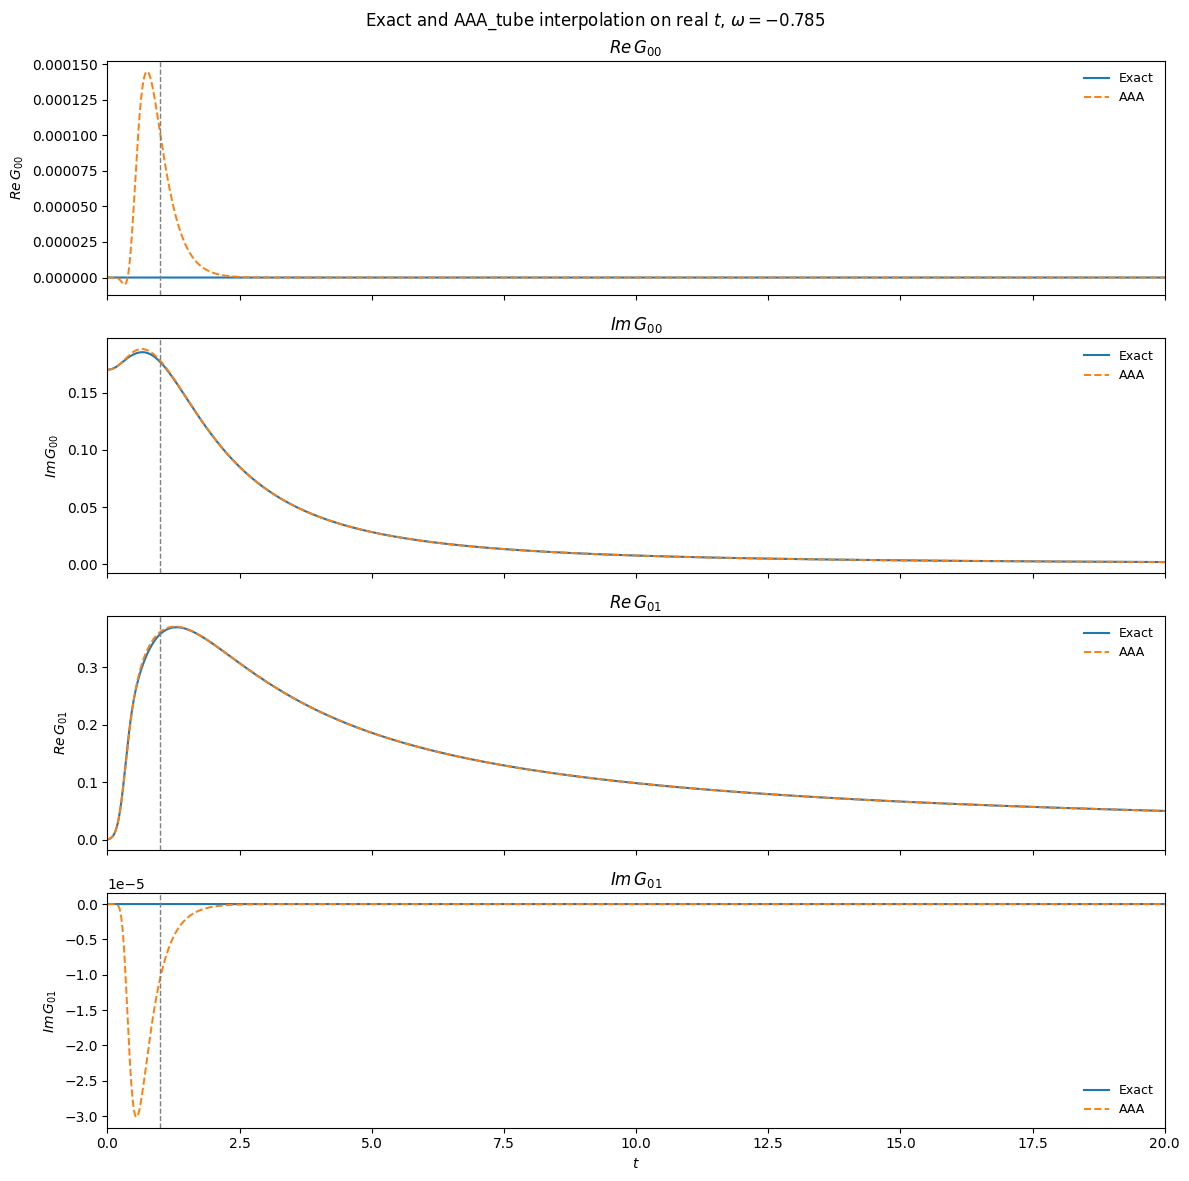

In [9]:
# Evaluate the fitted AAA rational functions on the real t axis.
t_real_eval = np.linspace(0, T, Nt)
G_exact_real = compute_exact_t(t_real_eval, np.array([wn[n_fit]]), U, beta)[:, 0]
G00_real = r00(t_real_eval)
G01_real = r01(t_real_eval)

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
real_axis_components = [
    (G_exact_real[:, 0, 0].real, G00_real.real, r"$Re\,G_{00}$"),
    (G_exact_real[:, 0, 0].imag, G00_real.imag, r"$Im\,G_{00}$"),
    (G_exact_real[:, 0, 1].real, G01_real.real, r"$Re\,G_{01}$"),
    (G_exact_real[:, 0, 1].imag, G01_real.imag, r"$Im\,G_{01}$"),
]

for ax, (exact_values, aaa_values, title) in zip(axes, real_axis_components):
    ax.plot(t_real_eval, exact_values, color="tab:blue", linewidth=1.5, label="Exact")
    ax.plot(t_real_eval, aaa_values, color="tab:orange", linestyle="--", linewidth=1.4, label="AAA")
    ax.axvline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(0, T)
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=9)

axes[-1].set_xlabel(r"$t$")
fig.suptitle(rf"Exact and AAA_tube interpolation on real $t$, $\omega={wn[n_fit]:.3g}$")
fig.tight_layout()
plt.show()


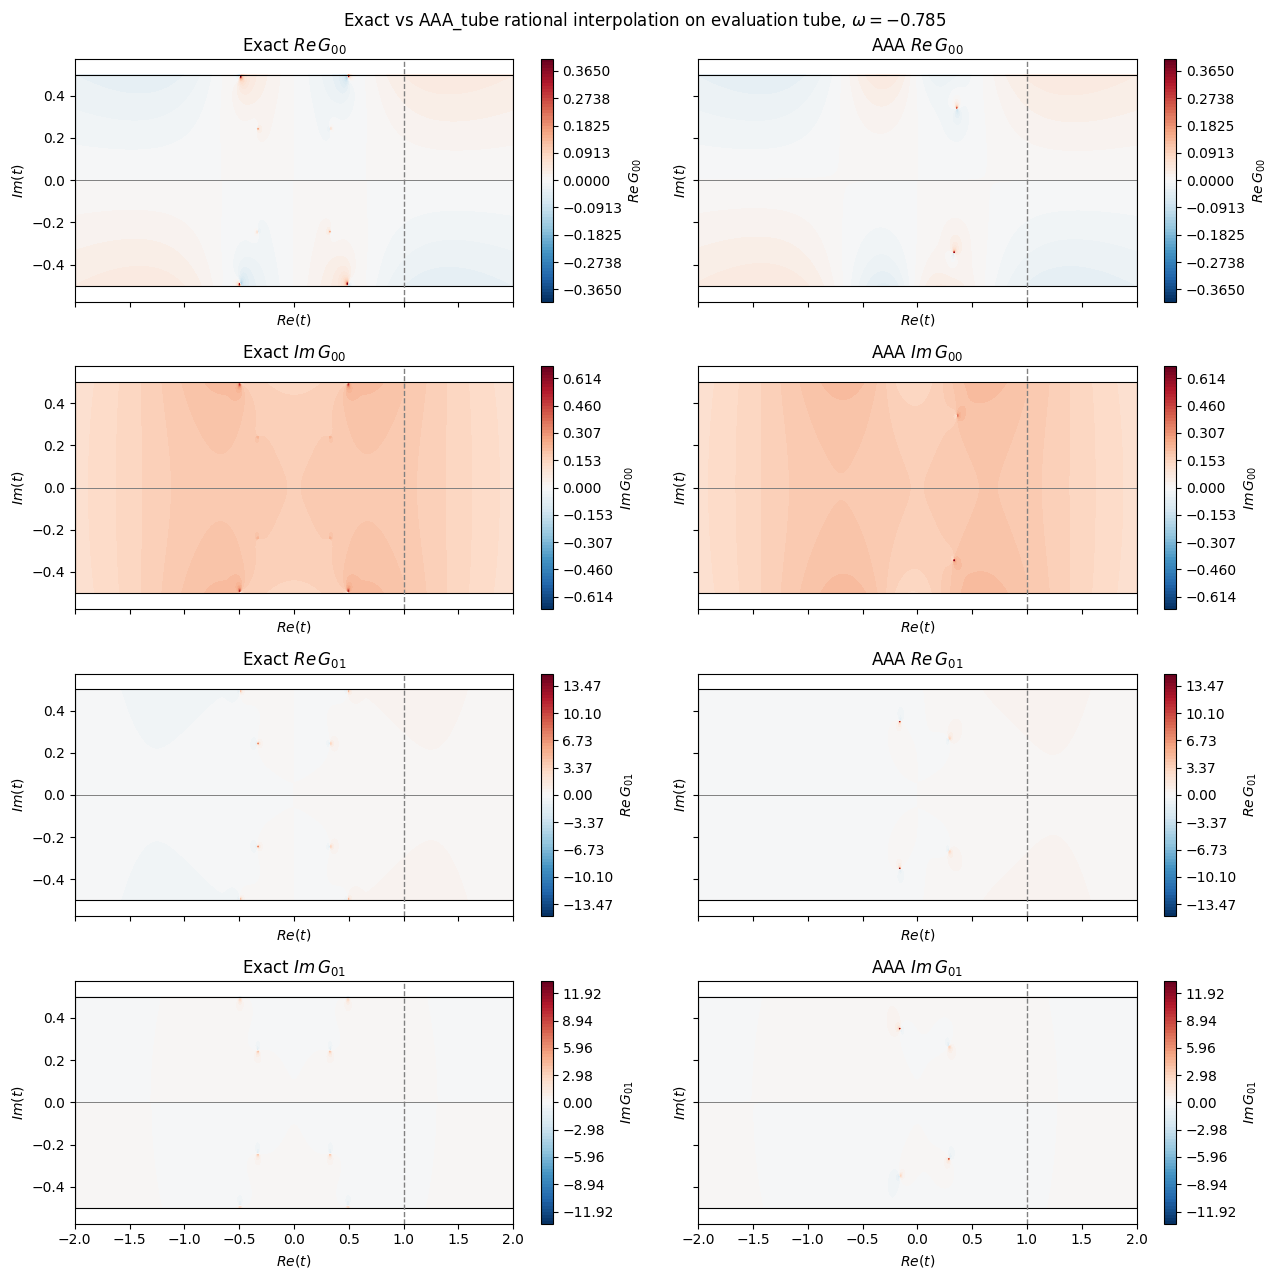

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(13, 13), sharex=True, sharey=True)
components = [
    (G_exact_eval[:, 0, 0].real, G00_eval.real, r"$Re\,G_{00}$"),
    (G_exact_eval[:, 0, 0].imag, G00_eval.imag, r"$Im\,G_{00}$"),
    (G_exact_eval[:, 0, 1].real, G01_eval.real, r"$Re\,G_{01}$"),
    (G_exact_eval[:, 0, 1].imag, G01_eval.imag, r"$Im\,G_{01}$"),
]

for row, (exact_values, aaa_values, title) in enumerate(components):
    exact_field = lattice_field(exact_values, tube_mask)
    aaa_field = lattice_field(aaa_values, tube_mask)
    vmax = np.nanmax(np.abs([exact_field, aaa_field]))
    levels = np.linspace(-vmax, vmax, 81) if vmax > 0 else 80

    panels = [
        (exact_field, "Exact " + title),
        (aaa_field, "AAA " + title),
    ]
    for col, (field, panel_title) in enumerate(panels):
        ax = axes[row, col]
        cf = ax.contourf(real_grid, imag_grid, field, levels=levels, cmap="RdBu_r")
        ax.plot(boundary.real, boundary.imag, color="k", linewidth=0.8)
        ax.axhline(0, color="0.5", linewidth=0.7)
        ax.axvline(1, color="gray", linestyle="--", linewidth=1)
        ax.set_ylim(-1.15 * eval_tube_delta, 1.15 * eval_tube_delta)
        ax.set_title(panel_title)
        ax.set_xlabel(r"$Re(t)$")
        ax.set_ylabel(r"$Im(t)$")
        fig.colorbar(cf, ax=ax, label=title)

fig.suptitle(rf"Exact vs AAA_tube rational interpolation on evaluation tube, $\omega={wn[n_fit]:.3g}$")
fig.tight_layout()
plt.show()


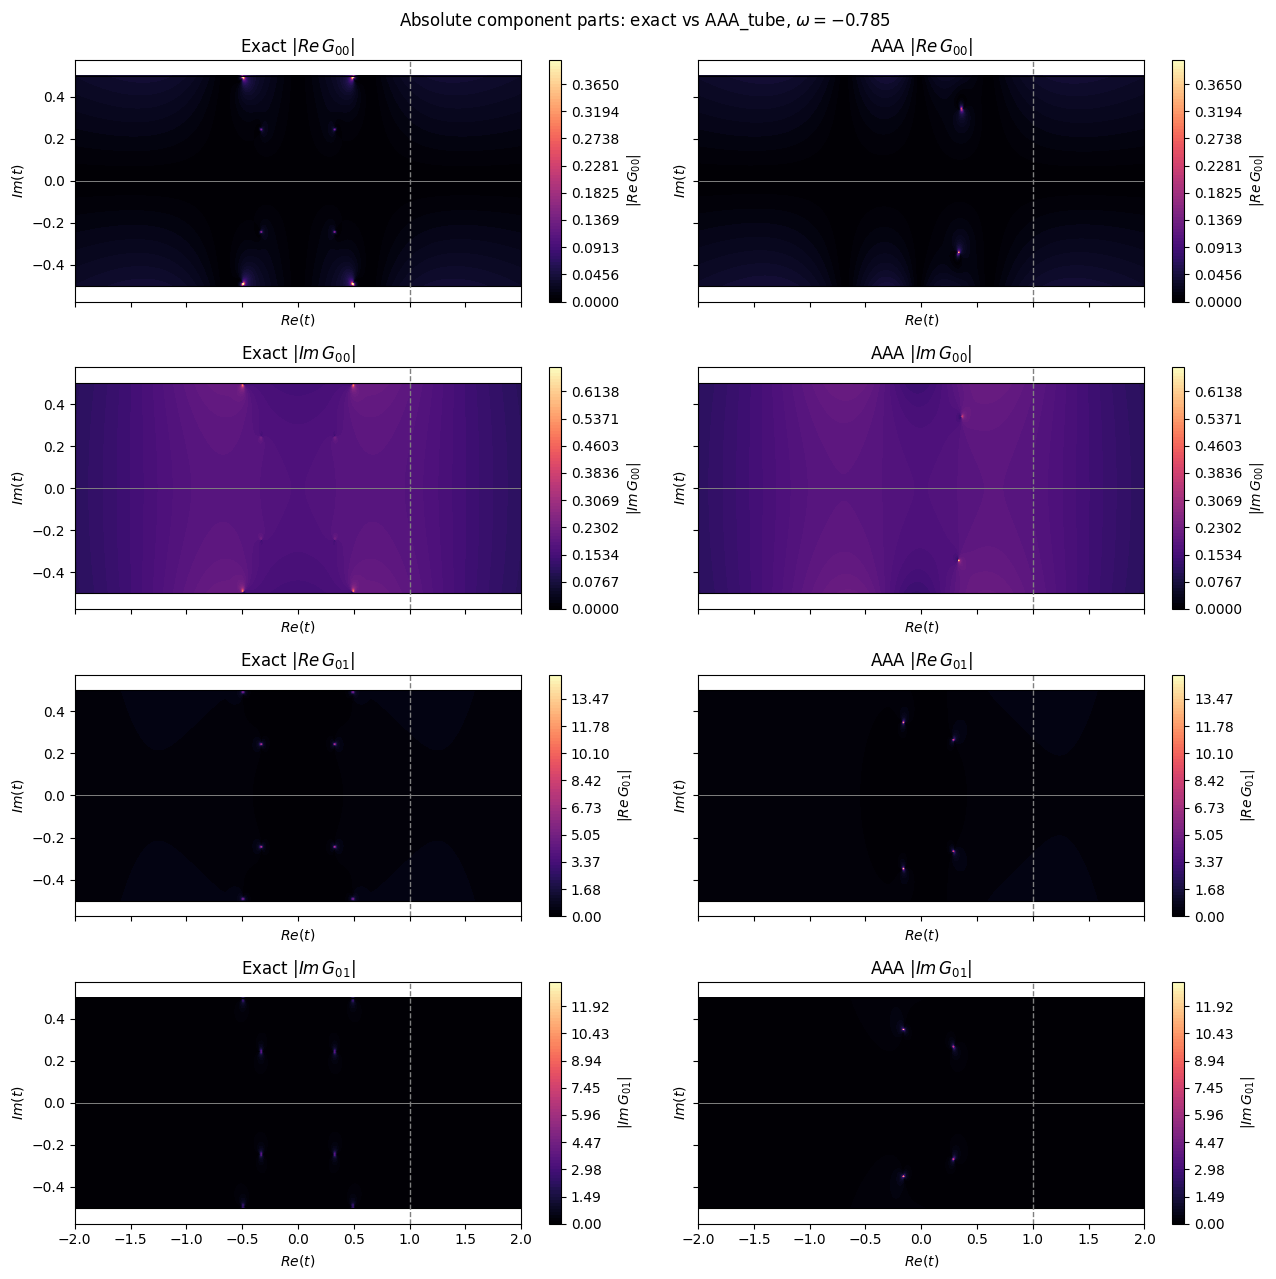

In [11]:
# Optional: plot absolute values of the real and imaginary parts, matching AAA_t_random_tube_exact.
fig, axes = plt.subplots(4, 2, figsize=(13, 13), sharex=True, sharey=True)
components_abs = [
    (np.abs(G_exact_eval[:, 0, 0].real), np.abs(G00_eval.real), r"$|Re\,G_{00}|$"),
    (np.abs(G_exact_eval[:, 0, 0].imag), np.abs(G00_eval.imag), r"$|Im\,G_{00}|$"),
    (np.abs(G_exact_eval[:, 0, 1].real), np.abs(G01_eval.real), r"$|Re\,G_{01}|$"),
    (np.abs(G_exact_eval[:, 0, 1].imag), np.abs(G01_eval.imag), r"$|Im\,G_{01}|$"),
]

for row, (exact_values, aaa_values, title) in enumerate(components_abs):
    exact_field = lattice_field(exact_values, tube_mask)
    aaa_field = lattice_field(aaa_values, tube_mask)
    vmax = np.nanmax([np.nanmax(exact_field), np.nanmax(aaa_field)])
    levels = np.linspace(0, vmax, 81) if vmax > 0 else 80

    panels = [
        (exact_field, "Exact " + title),
        (aaa_field, "AAA " + title),
    ]
    for col, (field, panel_title) in enumerate(panels):
        ax = axes[row, col]
        cf = ax.contourf(real_grid, imag_grid, field, levels=levels, cmap="magma")
        ax.plot(boundary.real, boundary.imag, color="k", linewidth=0.8)
        ax.axhline(0, color="0.5", linewidth=0.7)
        ax.axvline(1, color="gray", linestyle="--", linewidth=1)
        ax.set_ylim(-1.15 * eval_tube_delta, 1.15 * eval_tube_delta)
        ax.set_title(panel_title)
        ax.set_xlabel(r"$Re(t)$")
        ax.set_ylabel(r"$Im(t)$")
        fig.colorbar(cf, ax=ax, label=title)

fig.suptitle(rf"Absolute component parts: exact vs AAA_tube, $\omega={wn[n_fit]:.3g}$")
fig.tight_layout()
plt.show()
